In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Standard way to import Seaborn
import sklearn
from sklearn.datasets import make_classification

# Verify versions as per lab instructions
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.1.1
NumPy version: 1.24.4
Scikit-learn version: 1.3.1


In [6]:
# --- Configuration ---
N_SAMPLES = 1000
N_FEATURES = 20
N_INFORMATIVE = 10
N_REDUNDANT = 5 # This forces 5 features to be linear combinations of others
N_REPEATED = 0
N_CLASSES = 2

print("Generating synthetic dataset...")
X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=N_REPEATED,
    n_classes=N_CLASSES,
    n_clusters_per_class=2,
    flip_y=0.05,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(N_FEATURES)])
df['target'] = y

print(f"Dataset shape: {df.shape}")
df.head()

Generating synthetic dataset...
Dataset shape: (1000, 21)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,4.265400,-1.211650,0.796833,-0.109760,1.023434,-5.027231,-1.557087,3.771403,2.699267,0.632583,...,-2.269077,-6.145041,1.389293,-1.530884,-5.510158,-2.477942,-1.710175,1.953010,-1.242872,1
1,-1.744360,-1.308024,0.016525,0.945558,-0.757136,-4.747500,-1.428132,3.415792,-3.069724,-1.041453,...,0.548463,2.828816,-1.045195,-2.633928,3.608559,-0.915549,-0.390394,-2.686359,1.003366,0
2,1.561765,0.177521,-1.176465,1.562136,0.644545,-0.582877,0.100491,0.735118,0.391302,1.111953,...,-0.127159,0.741387,-1.435616,1.012254,-0.758513,-3.227830,0.577517,-0.155184,1.104478,0
3,1.306412,-0.550288,-0.761044,1.781720,-0.168626,-0.304995,0.705352,-2.972645,-2.632262,0.482713,...,-0.852573,3.227455,-0.595030,3.727947,-1.445978,-0.417116,-0.001515,0.931035,-0.413531,0
4,-7.352023,-0.834095,-0.303287,-1.766299,-1.260002,-1.519496,-3.811640,-0.896968,0.671243,-1.218176,...,-0.630232,3.368208,-1.772144,-2.778019,1.266388,4.327759,0.596081,-3.087178,0.396320,1


In [7]:
print("\nPerforming correlation analysis...")

# 1. Calculate the correlation matrix
correlation_matrix = df.corr()

# 2. Drop the target so we only look at Feature-to-Feature relationships
feature_correlation = correlation_matrix.drop('target', axis=1).drop('target', axis=0)

# 3. Identify Highly Correlated Features
threshold = 0.8
highly_correlated_pairs = set()

# Nested loop to check the lower triangle of the matrix (avoiding self-correlation)
for i in range(len(feature_correlation.columns)):
    for j in range(i):
        if abs(feature_correlation.iloc[i, j]) > threshold:
            colname_i = feature_correlation.columns[i]
            colname_j = feature_correlation.columns[j]
            # Store as a sorted tuple to prevent (A,B) and (B,A) duplicates
            pair = tuple(sorted((colname_i, colname_j)))
            highly_correlated_pairs.add(pair)

print(f"\nFound {len(highly_correlated_pairs)} highly correlated feature pairs:")
for pair in highly_correlated_pairs:
    print(f"- {pair[0]} and {pair[1]} (Correlation: {feature_correlation.loc[pair[0], pair[1]]:.2f})")


Performing correlation analysis...

Found 0 highly correlated feature pairs:


In [8]:
# --- Configuration Update ---
N_SAMPLES = 1000
N_FEATURES = 20
N_INFORMATIVE = 5  # Reduce this to make room for more redundancy
N_REDUNDANT = 10   # Increase this significantly
N_REPEATED = 0
N_CLASSES = 2

print("Generating synthetic dataset with high redundancy...")
X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    random_state=1 # Changing the seed often helps find high correlations
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(N_FEATURES)])
df['target'] = y

Generating synthetic dataset with high redundancy...


In [9]:
print("\nPerforming correlation analysis...")

# 1. Calculate the correlation matrix
correlation_matrix = df.corr()

# 2. Drop the target so we only look at Feature-to-Feature relationships
feature_correlation = correlation_matrix.drop('target', axis=1).drop('target', axis=0)

# 3. Identify Highly Correlated Features
threshold = 0.8
highly_correlated_pairs = set()

# Nested loop to check the lower triangle of the matrix (avoiding self-correlation)
for i in range(len(feature_correlation.columns)):
    for j in range(i):
        if abs(feature_correlation.iloc[i, j]) > threshold:
            colname_i = feature_correlation.columns[i]
            colname_j = feature_correlation.columns[j]
            # Store as a sorted tuple to prevent (A,B) and (B,A) duplicates
            pair = tuple(sorted((colname_i, colname_j)))
            highly_correlated_pairs.add(pair)

print(f"\nFound {len(highly_correlated_pairs)} highly correlated feature pairs:")
for pair in highly_correlated_pairs:
    print(f"- {pair[0]} and {pair[1]} (Correlation: {feature_correlation.loc[pair[0], pair[1]]:.2f})")


Performing correlation analysis...

Found 7 highly correlated feature pairs:
- feature_17 and feature_19 (Correlation: 0.89)
- feature_0 and feature_12 (Correlation: -0.80)
- feature_0 and feature_1 (Correlation: -0.88)
- feature_1 and feature_12 (Correlation: 0.91)
- feature_17 and feature_7 (Correlation: -0.84)
- feature_2 and feature_4 (Correlation: -0.83)
- feature_2 and feature_8 (Correlation: -0.81)


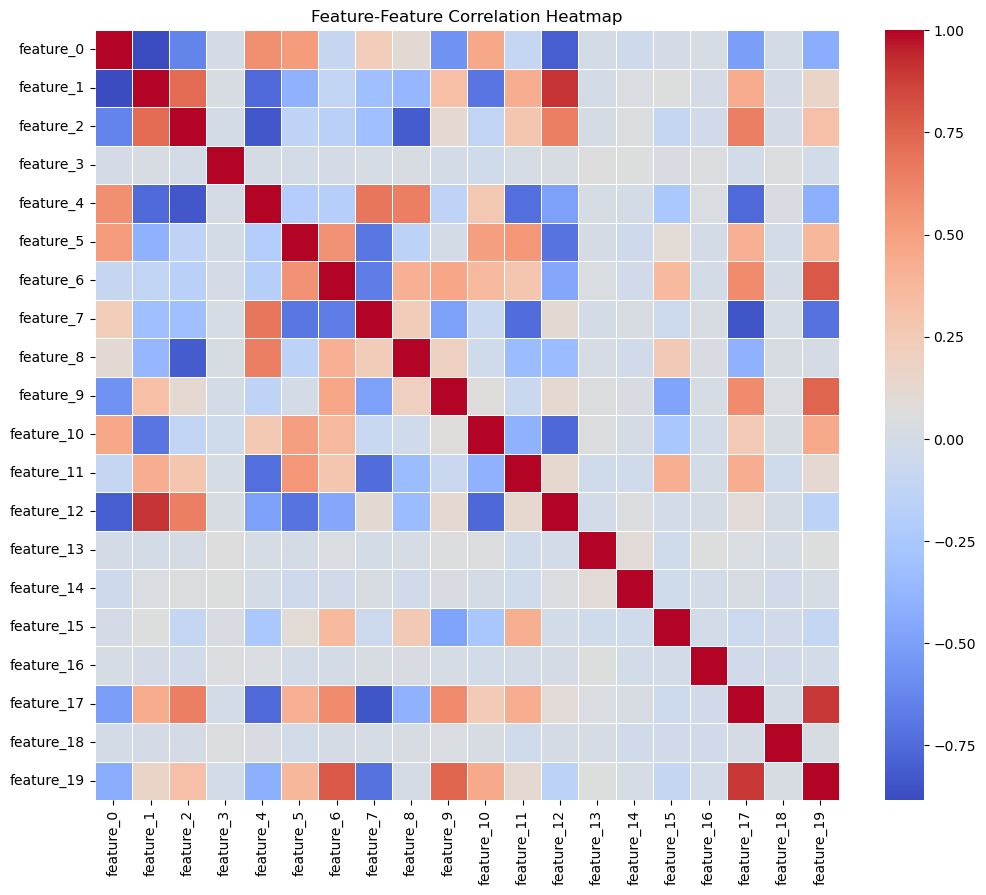


Correlation analysis complete. Identified redundant features.


In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(feature_correlation, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature-Feature Correlation Heatmap')
plt.show()

print("\nCorrelation analysis complete. Identified redundant features.")

Original number of features: 20
Reduced number of components: 9
Total Variance Retained: 95.81%


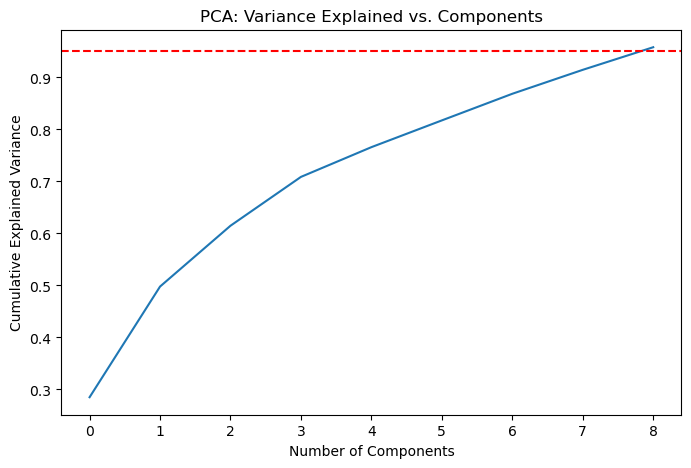

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardization: Essential for PCA as it's sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X is from our synthetic data

# 2. Apply PCA: Retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3. Evaluate the Reduction
print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of components: {X_pca.shape[1]}")
print(f"Total Variance Retained: {np.sum(pca.explained_variance_ratio_):.2%}")

# Optional: Visualize the Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Variance Explained vs. Components')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()